In [1]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network


## Loading the Data

In [2]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [3]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [4]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

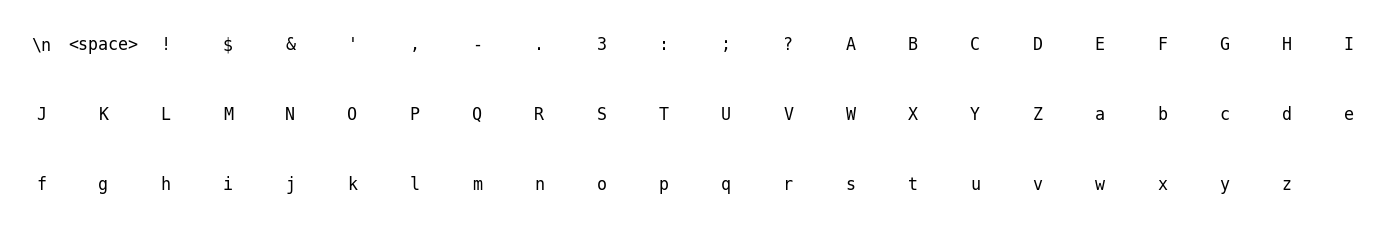

In [5]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [7]:
embedding_dim = 64
hidden_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "GatedRecurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Softmax", "input_size": hidden_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: GatedRecurrentLayer
  Weights Shape: (64, 768) | Recurrent Weights Shape: (256, 768) | Biases Shape: (768,)
  Parameters: 246,528

Layer 3: SoftmaxLayer
  Weights Shape: (256, 65) | Biases Shape: (65,)
  Parameters: 16,705

Total Parameters: 267,393


c:\Users\DANIELPEDERZINI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training the Model

In [8]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [9]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [10]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [11]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [12]:
sequence_length = 164
batch_size = 64
epochs = 500
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.05
min_learning_rate = 0.001
weight_decay_lambda = 1e-4
momentum = 0.9
early_stopping_patience = 20

In [13]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
        momentum=momentum,
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 50 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break


{'epoch': 1, 'learning_rate': 0.05, 'train_perplexity': 20.596535722966404, 'test_perplexity': 13.7806395833669}
{'epoch': 50, 'learning_rate': 0.04884799386717187, 'train_perplexity': 5.294959097179468, 'test_perplexity': 5.5471475865104445}
{'epoch': 100, 'learning_rate': 0.045411007028610804, 'train_perplexity': 4.501065610581412, 'test_perplexity': 4.938621168158157}
{'epoch': 150, 'learning_rate': 0.04002499209394596, 'train_perplexity': 4.1235234412225745, 'test_perplexity': 4.722761041870218}
{'epoch': 200, 'learning_rate': 0.03321716973155497, 'train_perplexity': 3.889583718909872, 'test_perplexity': 4.630434021102193}
{'epoch': 250, 'learning_rate': 0.0256539370271562, 'train_perplexity': 3.7307328659285424, 'test_perplexity': 4.597584589286351}
{'epoch': 300, 'learning_rate': 0.018075635893997043, 'train_perplexity': 3.620290019005325, 'test_perplexity': 4.592001923443169}
Early stopping triggered after 311 epochs due to no improvement.


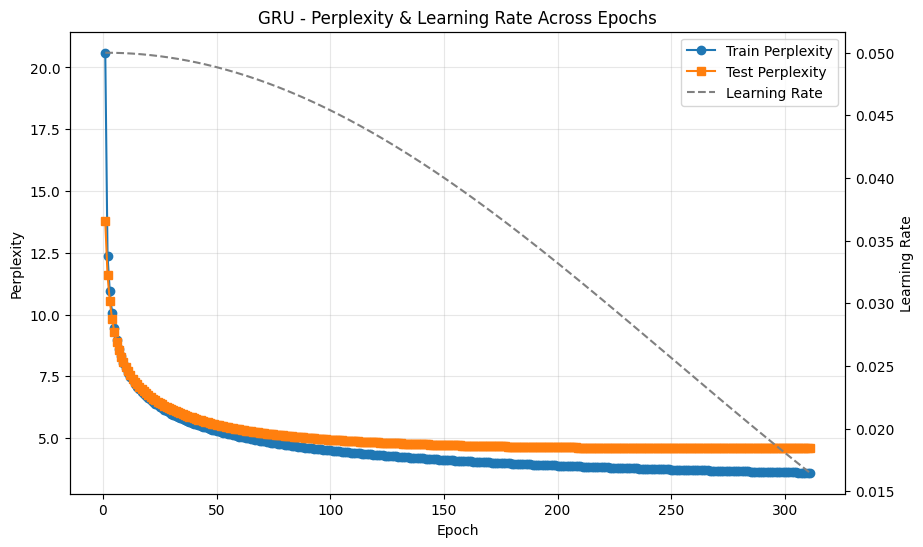

In [14]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("GRU - Perplexity & Learning Rate Across Epochs")
plt.show()

In [34]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [40]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.9, print_during=True)

DANIEL:
Thom a bloody follow, sir, as I,
She he store than the reparel him.

BAt are me with his worst it,
With teels, but me through in the sworn the difined
Feelves to the world and done of his thricks?
For have them bold, and friends: have sworn his word Lancora,
And the need appeace to at; of me,
Call before you can not slander.

MERCUTIO:
Alas, here entleman with a little herefore for the out,
That honour'd thee and are of coverusa
that thou blood sake it, for I mether, cowns, besides them,
That pains here canst free and me Butcheries;
And I murder be noble honours throne.

QUEEN:
Some, and flamned him, but glory hafge me,
And set you have the was right of night,
As ignorievic blo, married to want of whicher's laument if
these will not heard he down by a
crown, to sea mone at the noble upon you cousin
Where tonguiment, how I speak, where nor tell you,
Take me when he returer's purpose three south,
But must intemptod sic, not to-morrow,
Where common you, lork to the may anvingry sh

In [41]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIELA:
It is thy dones not appealings
Than the change of the me.

MENENIUS:
Nay, nor shall in the savely greater,
And see the learnet his promised therefore not
cannot prove, for me to my spurn which
sheeping on the tongue of winter, sir,
I'll was any ancient die.

LUCIO:
Why, then he be it burred years dead,
Or ever maid of this night of this name to the post,
When the body than thee deppress me, and thy confess.

BUCKINGHAM:
Why, sir, I thousand supper this in the fly?

Second Servant:
Mark gone, for your father body and fraint,
And there, could have shalt thou wilt have are night
To be find with his foot out of you
would as sweet words and fruited my speed.

Second Citizen:
Almost should little are thou is your storse
And what his pleamine shouldly time with this is true tide,
Which feel the difference to him; his husband
Dight it under might my heart man boy!

GONDER:
What do lie you the presently,
I forswor, but like a pursued worse, beyling one than to dies,
And my free of him 

In [42]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.5, print_during=True)

DANIELA:
And thou strength that beseech my lord.

CORIOLANUS:
For though art to him:
Have strength the earth to be better to my father,
Leave you this first be with me that boy.

GLOUCESTER:
I have have speak to the rest the earth.

LEONTES:
What cannot satisfied
That was not for the boldness in his here from the dukes,
With a little of the lands and love him thousand sensel honours
Than the fall you have man from of friends
And heart thee to see the warlike their child,
I have were speak the well to the presence and the world,
Which one that we have here of whom the poison?

SICINIUS:
Then are you shall find the truth the house.

COMINIUS:
Why, have shall stay
That beseech you have may begin else to some true.

LUCENTIO:
Here the common of this place to the mind.

CLARENCE:
Have me you have length of love a man, which thousand have perpent as I think the cords
Of the world be maid us all the own.

COMINIUS:
Now, noble that he shall please the child
My noble true so great from that sho

In [43]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.3, print_during=True)

DANIELA:
A make me to accuse the man:
We are the bring the most be report.

BRUTUS:
Methinks, and therefore he did before you have been a son.

PETRUCHIO:
I am a fair souls are not so stands are not
To an end of this death, and the present and what resolved
With the proveth him be content, and such a mind,
The maid of the reckong the common many and sometimes
As the content the comming that thou art to the more than the son,
And when the duke of the world the patter, and the strike a word to the law
the norther and his hold things of the world
I would stay and the spent of the house of the should
That we shall see the king and men and death,
And so breathe that hath a widowed to the company.

Provost:
How now, my lord, and the rest the consent for the most and his heart.

LUCIO:
No, my lord, and the sea was with the consul
That we so shall we shall be son,
The son all the world, and we have been a band of the fair of the present and men
To say you have not be so dispatch of the maintio